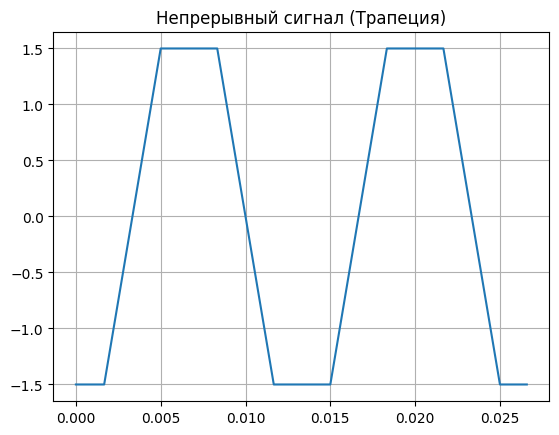

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import sawtooth

# 1. Параметры сигнала (Вариант 9)
T = 75                      # Частота сигнала, Гц
points_per_period = 160     # Количество точек на 1 период для гладкости
fs = points_per_period * T  # Частота дискретизации
h = 1 / fs                  # Шаг дискретизации
tsign = 2 * (1 / T)         # Время двух периодов
N = int(tsign * fs)         # Общее количество точек (приводим к целым!)

# 2. Временная сетка
t = np.arange(N) * h

# 3. Генерация трапецеидального сигнала (Вариант 9, График 3)
w = 2 * np.pi * T
# Сначала делаем треугольный сигнал (width=0.5)
raw_triangle = sawtooth(w * t, width=0.5)
# "Срезаем" вершины с помощью clip, чтобы получить плоскую трапецию
# Амплитуду ставим 1.5 В, чтобы она красиво укладывалась в будущий АЦП диапазон +-2 В
u = np.clip(raw_triangle * 3.0, -1.5, 1.5)

# 4. Построение непрерывного графика
plt.figure(1)
plt.plot(t, u)
plt.grid()
plt.title('Непрерывный сигнал (Трапеция)')
plt.show()  # Оставьте обычный show(), чтобы график не закрывался мгновенно


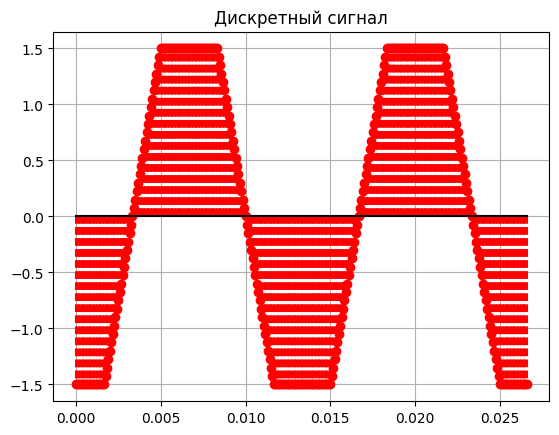

In [13]:
# Строит сигнал в виде вертикальных отсчетов
plt.figure(2)
plt.stem(t, u, linefmt='r--', markerfmt='ro', basefmt='k-')
plt.grid()
plt.title('Дискретный сигнал')
plt.show()


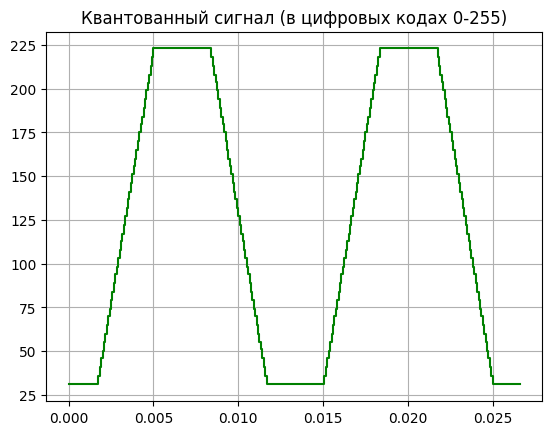

In [14]:
# Параметры АЦП по условию задачи
n = 8                   # Разрядность (8 бит дает диапазон кодов от 0 до 255)
Smin, Smax = -2.0, 2.0  # Границы входного диапазона АЦП в Вольтах

# Прямое преобразование: перевод амплитуды в цифровой код по формуле (2)
ukod = np.floor((u - Smin) / (Smax - Smin) * (2**n - 1))

# Ступенчатый график цифровых кодов на выходе АЦП
plt.figure(3)
plt.step(t, ukod, where='post', color='g')
plt.grid()
plt.title('Квантованный сигнал (в цифровых кодах 0-255)')
plt.show()


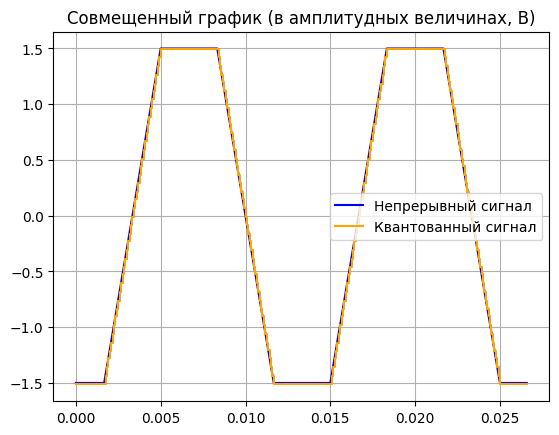

In [15]:
# Обратное преобразование: перевод кодов обратно в Вольты по формуле (3)
u_kvant = ukod / (2**n - 1) * (Smax - Smin) + Smin

# Построение в одних осях исходного и ступенчатого квантованного сигналов
plt.figure(4)
plt.plot(t, u, label='Непрерывный сигнал', color='b')
plt.step(t, u_kvant, where='post', label='Квантованный сигнал', color='orange')
plt.grid()
plt.legend()
plt.title('Совмещенный график (в амплитудных величинах, В)')
plt.show()
